In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import joblib
from scipy.sparse import load_npz
import numpy as np


data = joblib.load('/content/drive/MyDrive/Colab Notebooks/data project 1 AI Indonesia/Individual Project/TF-IDF&LogisticRegression/data/alldata_tfidf_optimal.pkl')
x_train = data['x_train_tfidf_optimal']
x_test = data['x_test_tfidf_optimal']
y_train = data['y_train_enc']
y_test = data['y_test_enc']
tfidf = data['tfidf_optimal']
encoder = data['encoder']

In [3]:
# ============================================
# PERCOBAAN 6: VARIASI SOLVER
# ============================================

from sklearn.linear_model import LogisticRegression

solvers = ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga']
accuracies_solver = []

print("📊 Eksperimen dengan berbagai solver:")
for solver in solvers:
    try:
        lr = LogisticRegression(solver=solver, max_iter=1000, random_state=42)
        lr.fit(x_train, y_train)
        acc = lr.score(x_test, y_test)
        accuracies_solver.append(acc)
        print(f"   {solver}: {acc:.4f}")
    except:
        accuracies_solver.append(0)
        print(f"   {solver}: error")

📊 Eksperimen dengan berbagai solver:
   lbfgs: 0.6088
   liblinear: 0.5923
   newton-cg: 0.6116
   sag: 0.6088
   saga: 0.6088


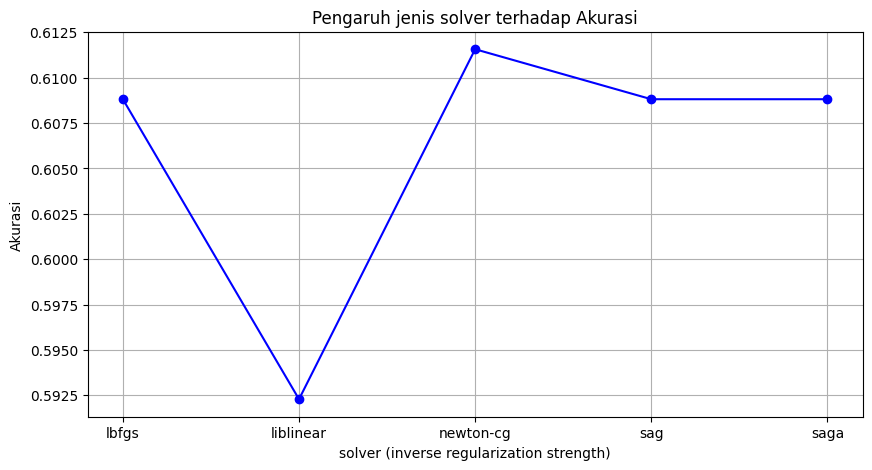

In [5]:
# Visualisasi

import matplotlib.pyplot as plt

# Plot akurasi berdasarkan nilai C

plt.figure(figsize=(10, 5))
plt.plot(solvers, accuracies_solver, 'bo-')
plt.xlabel('solver (inverse regularization strength)')
plt.ylabel('Akurasi')
plt.title('Pengaruh jenis solver terhadap Akurasi')
plt.grid(True)
plt.show()